In [34]:
from collections import defaultdict

from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env

In [35]:
# Initialize an OpenCL environment. You can change i_platform to select the device to use.
init_env(i_platform=0)

Initializing an OpenCL environment on NVIDIA CUDA


In [36]:
# Load sample coordinates (xyzs), atomic numbers (Zs), and charges (qs)
xyzs, Zs, qs, _ = loadXYZ("materials/pt_111_small_1_3_vacancies.xyz")

# Create an instance of the simulator
# afmulator = AFMulator(
#     # scan_dim=(201, 201, 51),
#     # scan_window=((45.0, 25.0, 16), (60.0, 50.0, 19)),
#     df_steps=1,
#     # iZPP=8,
#     # tipR0=[0.0, 0.0, 3.0]
# )
afmulator = AFMulator.from_params("materials/params_code.ini")
# df_steps is calculated by dividing amplitude by scanStep in z dir
# afmulator.setScanWindow(df_steps=20)

sigma:  0.7
Spherical harmonic: s


In [37]:
# Run the simulation and plot the resulting images
afm_images = afmulator(xyzs, Zs, qs, plot_to_dir="output")

sigma:  0.7
Spherical harmonic: s
 plotting slice # 250

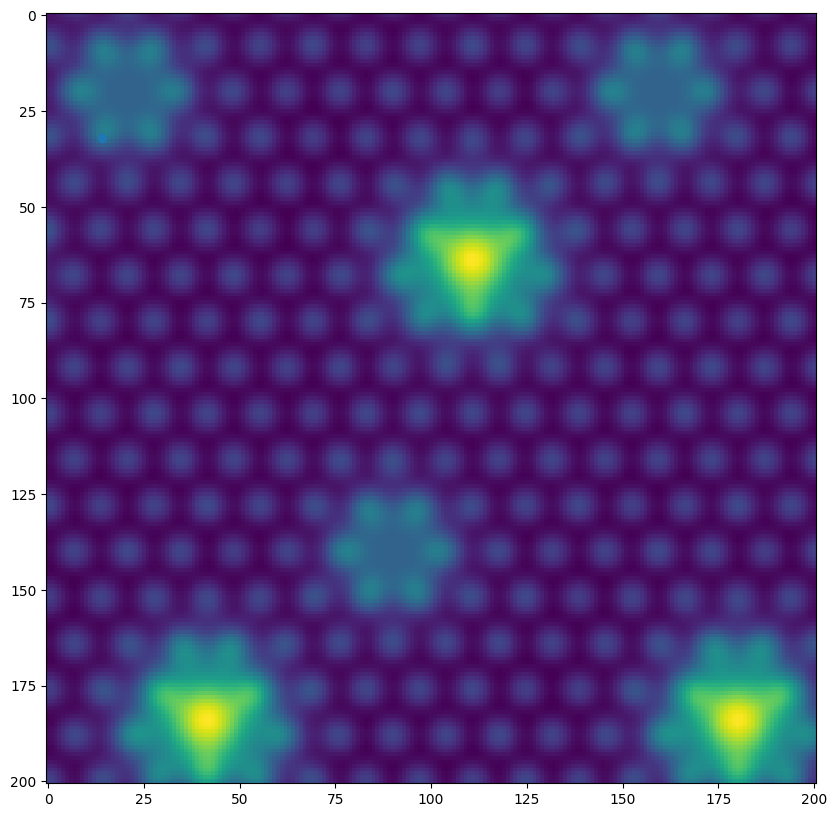

In [45]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] =  [10, 10]

def plot_surface(img, vmin=None, vmax=None):
    plt.imshow(img[:,::-1].T, vmin=vmin, vmax=vmax)
    
plot_surface(afm_images[:,:,188])
plt.scatter(14, 32)

In [4]:
import numpy as np
z = np.linspace(
            afmulator.scan_window[0][2],
            afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
            afmulator.scan_dim[2] - afmulator.df_steps + 1,
        )

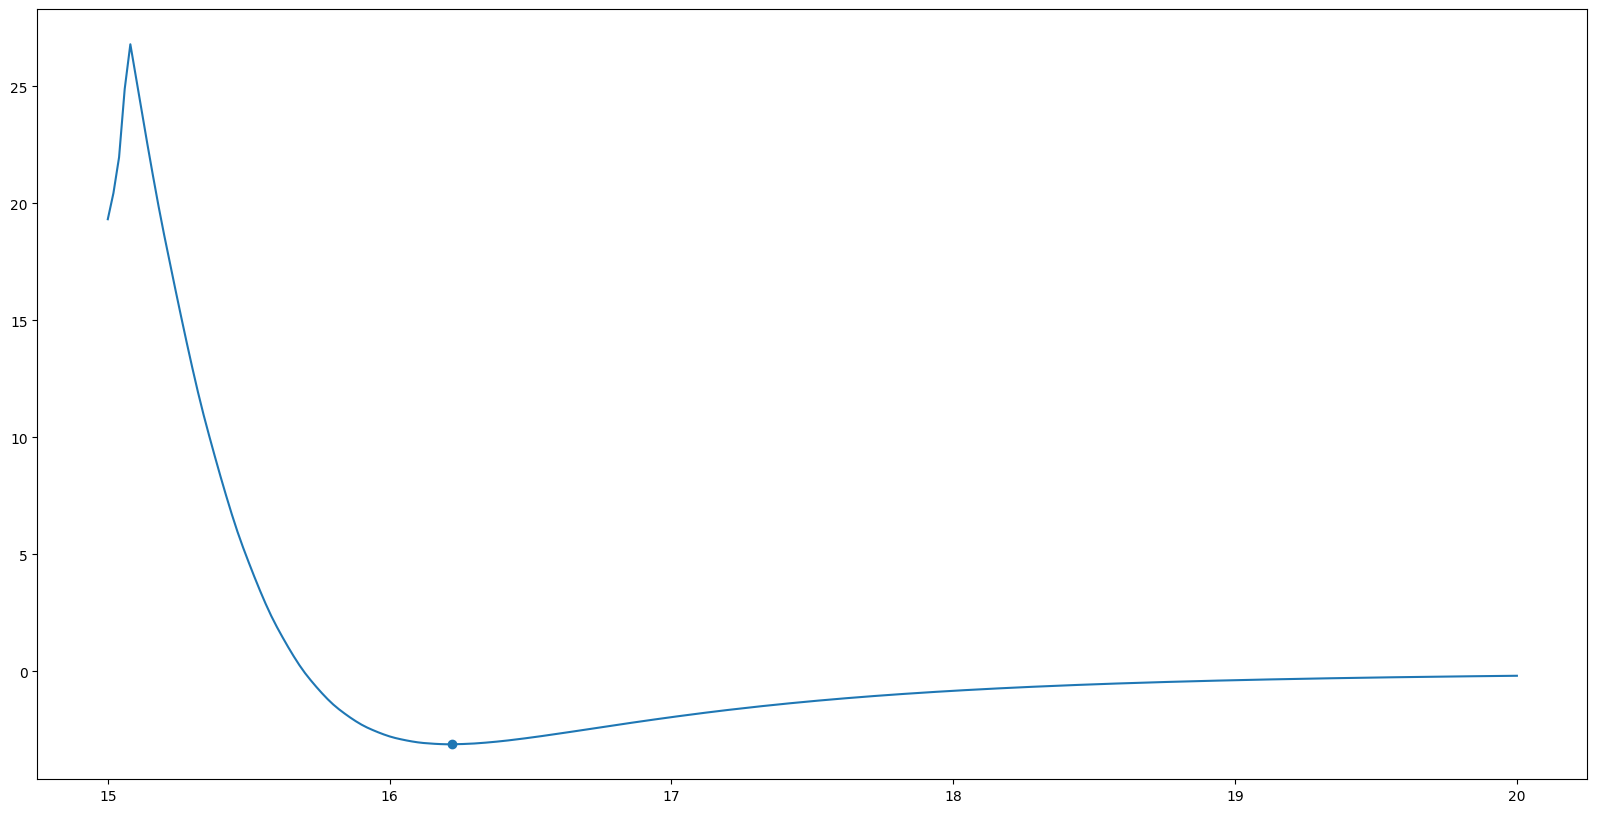

In [5]:
x, y = 14, 32
#plt.plot(z, afm_images[14, 32, :])
plt.plot(z, afm_images[x, y, :])
plt.scatter(z[np.argmin(afm_images, axis=2)[x, y]], afm_images[x,y, np.argmin(afm_images, axis=2)[x, y]])

#plt.xlim(18.5, 19.5)
#plt.ylim(-3.3, -2)

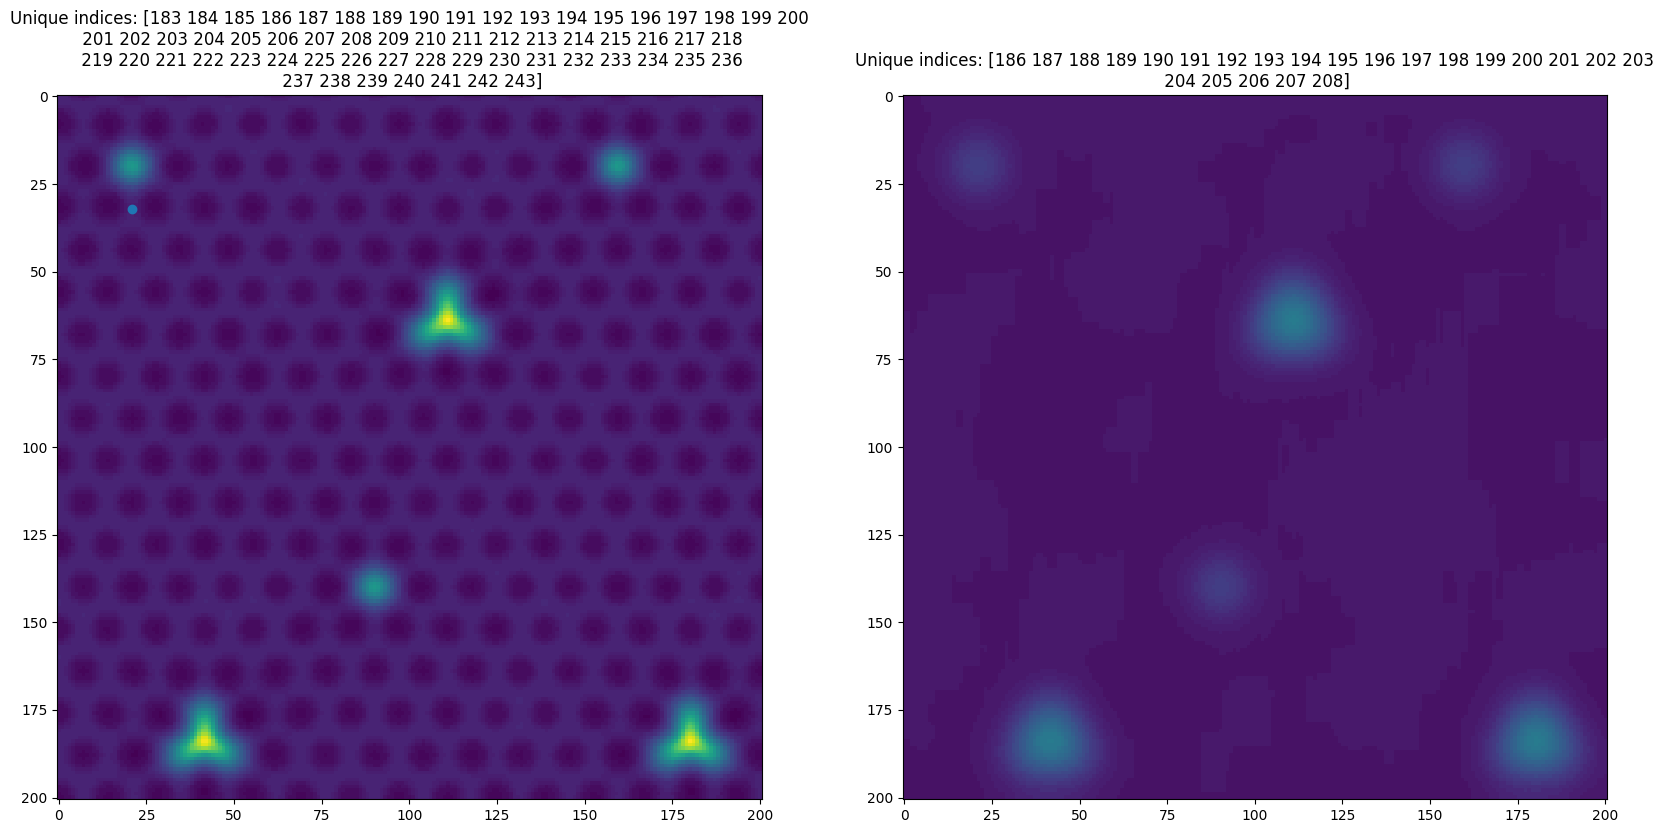

In [46]:
from scipy.ndimage import gaussian_filter

plt.rcParams["figure.figsize"] =  [20, 10]

min_image = np.argmin(afm_images, axis=2)
blurred_image = gaussian_filter(min_image, sigma=6)
vmin = np.min(min_image)
vmax = np.max(min_image)

plt.subplots(1, 2)

plt.subplot(1, 2, 1)
plt.title(f"Unique indices: {np.unique(min_image)}")
plot_surface(min_image, vmin=vmin, vmax=vmax)
plt.scatter(21, 32)

plt.subplot(1, 2, 2)
plt.title(f"Unique indices: {np.unique(blurred_image)}")
plot_surface(blurred_image, vmin=vmin, vmax=vmax)

In [42]:
x, y = 21, 32
print(np.median(np.argmin(afm_images, axis=2)))
print(afm_images[x, y, 188])
print(np.argmin(afm_images, axis=2)[x, y])
z[np.argmin(afm_images, axis=2)[x, y]]

188.0
-2.9196672
186


18.72

In [43]:
unique_vals = np.unique(np.argmin(afm_images, axis=2))
print(z[unique_vals[0]], z[unique_vals[-1]])

18.66 19.86


In [7]:
from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema
import numpy as np
from collections import defaultdict

def plot_surface(img, vmin=None, vmax=None):
    plt.imshow(img.T, vmin=vmin, vmax=vmax)
    
def compute_imgs(path_surface):
    init_env(i_platform=0)
    xyzs, Zs, qs, _ = loadXYZ(path_surface)
    afmulator = AFMulator.from_params("materials/params_code.ini")
    afm_images = afmulator(xyzs, Zs, qs)#, plot_to_dir="output")
    
    return afmulator, afm_images
    
    
def argmin_surface_and_blur(afmulator, afm_images, xy=(32, 14)):
    # if compute_img:
    # init_env(i_platform=0)
    # xyzs, Zs, qs, _ = loadXYZ(path_surface)
    # afmulator = AFMulator.from_params("materials/params_code.ini")
    # afm_images = afmulator(xyzs, Zs, qs, plot_to_dir="output")[:,:,::-1]
    
    plt.rcParams["figure.figsize"] =  [20, 10]
    
    afm_images_transformed = afm_images[:,::-1,::-1]
    
    minima = np.array(argrelextrema(afm_images_transformed, np.less_equal, axis=2)).T
    minima_dict = defaultdict(list)
    for x, y, z in minima:
        minima_dict[x, y].append(z)
        minima_dict[x, y] = [max(minima_dict[x, y])]
    
    argmin_image = np.zeros(afm_images_transformed.shape[0:-1], dtype=int)
    for pixel, val in minima_dict.items():
        argmin_image[pixel] = int(val[0])
    
    xy = np.array(xy)
    
    z = np.linspace(
                afmulator.scan_window[0][2],
                afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
                afmulator.scan_dim[2] - afmulator.df_steps + 1,
    )
    
    min_image = z[argmin_image]
    #min_image = z[np.argmin(afm_images_transformed, axis=2)]
    blurred_image = gaussian_filter(min_image, sigma=6)
    vmin = np.min(min_image)
    vmax = np.max(min_image)
    
    plt.subplots(1, 2)
    
    plt.subplot(1, 2, 1)
    plt.title(f"Unique indices: {np.unique(min_image)}")
    plot_surface(min_image, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.scatter(xy[0], xy[1], color='red')
    plt.tight_layout()
    
    plt.subplot(1, 2, 2)
    plt.title(f"Unique indices: {np.unique(blurred_image)}")
    plot_surface(blurred_image, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.scatter(xy[0], xy[1], color='red')
    plt.tight_layout()
    
    plt.show()
    
    minima = argrelextrema(afm_images_transformed[xy[0], xy[1]], np.less_equal)#[xy[0], xy[1]]
    #print(minima[0])
    
    plt.plot(z, afm_images_transformed[xy[0], xy[1], :])
    #plt.scatter(z[np.argmin(afm_images_transformed, axis=2)[xy[0], xy[1]]], afm_images_transformed[xy[0],xy[1], np.argmin(afm_images_transformed, axis=2)[xy[0], xy[1]]])
    for minimum in minima:
        plt.scatter(z[minimum], afm_images_transformed[xy[0], xy[1], minimum])
    
    plt.show()
    
    return min_image, blurred_image
    

In [2]:
afmulator, afm_images = compute_imgs("materials/pt_111_small_rows_missing.xyz")

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


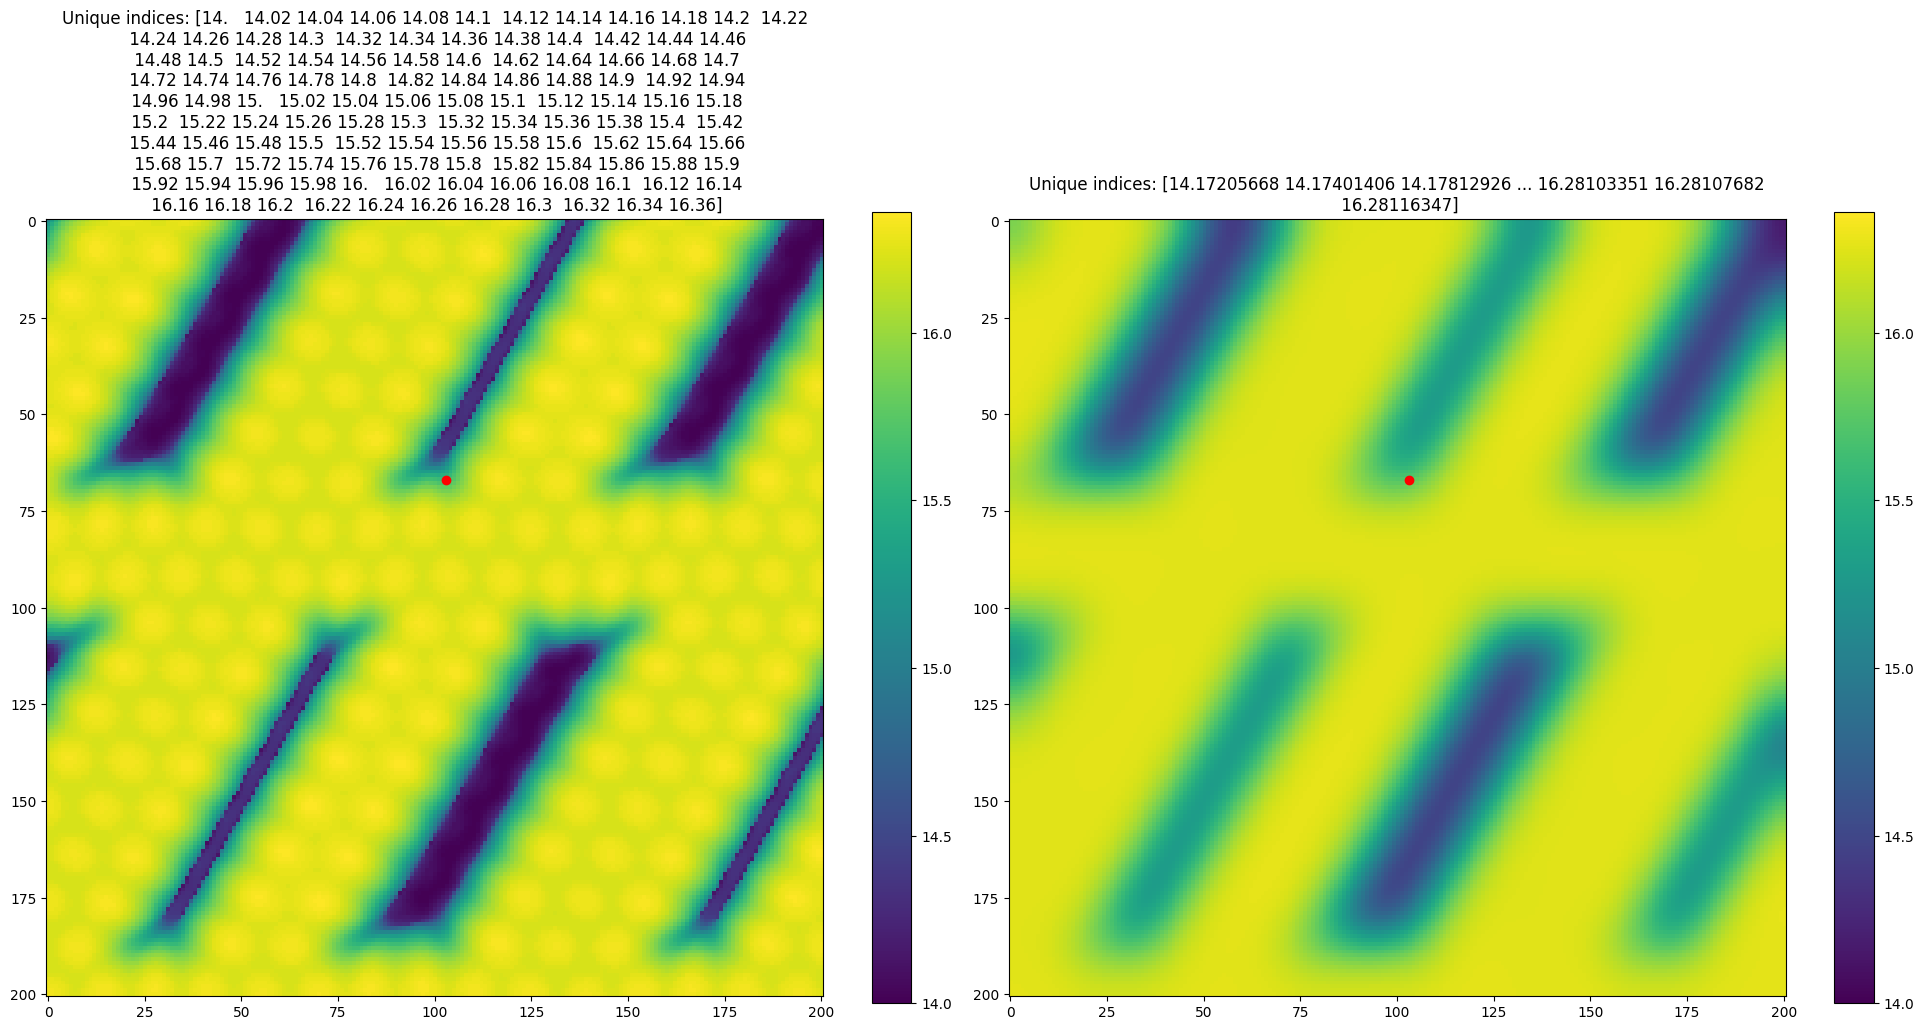

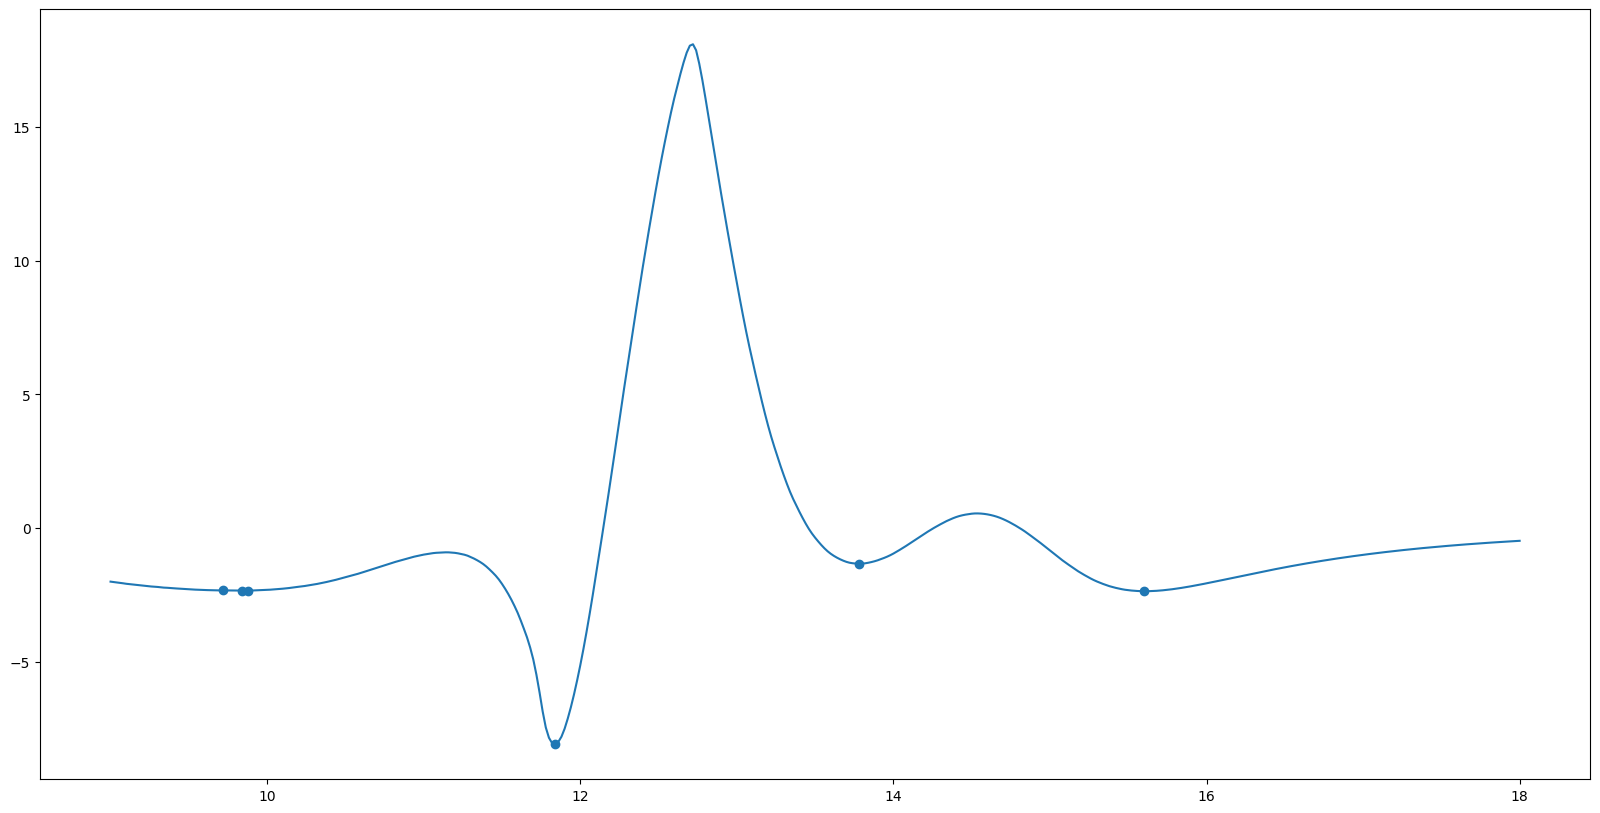

In [8]:
# pt_111_smal_1_3_vacancies.xyz
xy_3_vacancy = (118, 69)
xy_1_vacancy = (21, 25)

# pt_111_small_rows_missing.xyz
xy_2row_corner = (103, 67)
xy_3row_corner = (146, 67)
xy_3row_middle = (171, 44)
xy_reference = (77, 67)

xy_test = (162, 44)
xy_test = (200, 200)

min_image, blurred_image = argmin_surface_and_blur(afmulator, afm_images, xy=xy_2row_corner)

In [54]:
from collections import defaultdict
afm_images_transformed = afm_images[:,::-1,::-1]
minima = np.array(argrelextrema(afm_images_transformed, np.less_equal, axis=2)).T
minima_dict = defaultdict(list)
for x, y, z in minima:
    minima_dict[x, y].append(z)
    minima_dict[x, y] = [max(minima_dict[x, y])]

min_image = np.zeros(afm_images_transformed.shape[0:-1], dtype=int)
for pixel, val in minima_dict.items():
    min_image[pixel] = val[0]
    
z = np.linspace(
                afmulator.scan_window[0][2],
                afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
                afmulator.scan_dim[2] - afmulator.df_steps + 1,
    )

z[min_image]

array([[15.08, 15.26, 15.36, ..., 16.3 , 16.32, 16.32],
       [15.34, 15.46, 15.54, ..., 16.3 , 16.32, 16.32],
       [15.52, 15.6 , 15.68, ..., 16.3 , 16.3 , 16.3 ],
       ...,
       [14.04, 14.04, 14.02, ..., 16.26, 16.28, 16.28],
       [14.02, 14.02, 14.  , ..., 16.24, 16.26, 16.26],
       [14.  , 14.  , 14.  , ..., 16.24, 16.24, 16.24]])

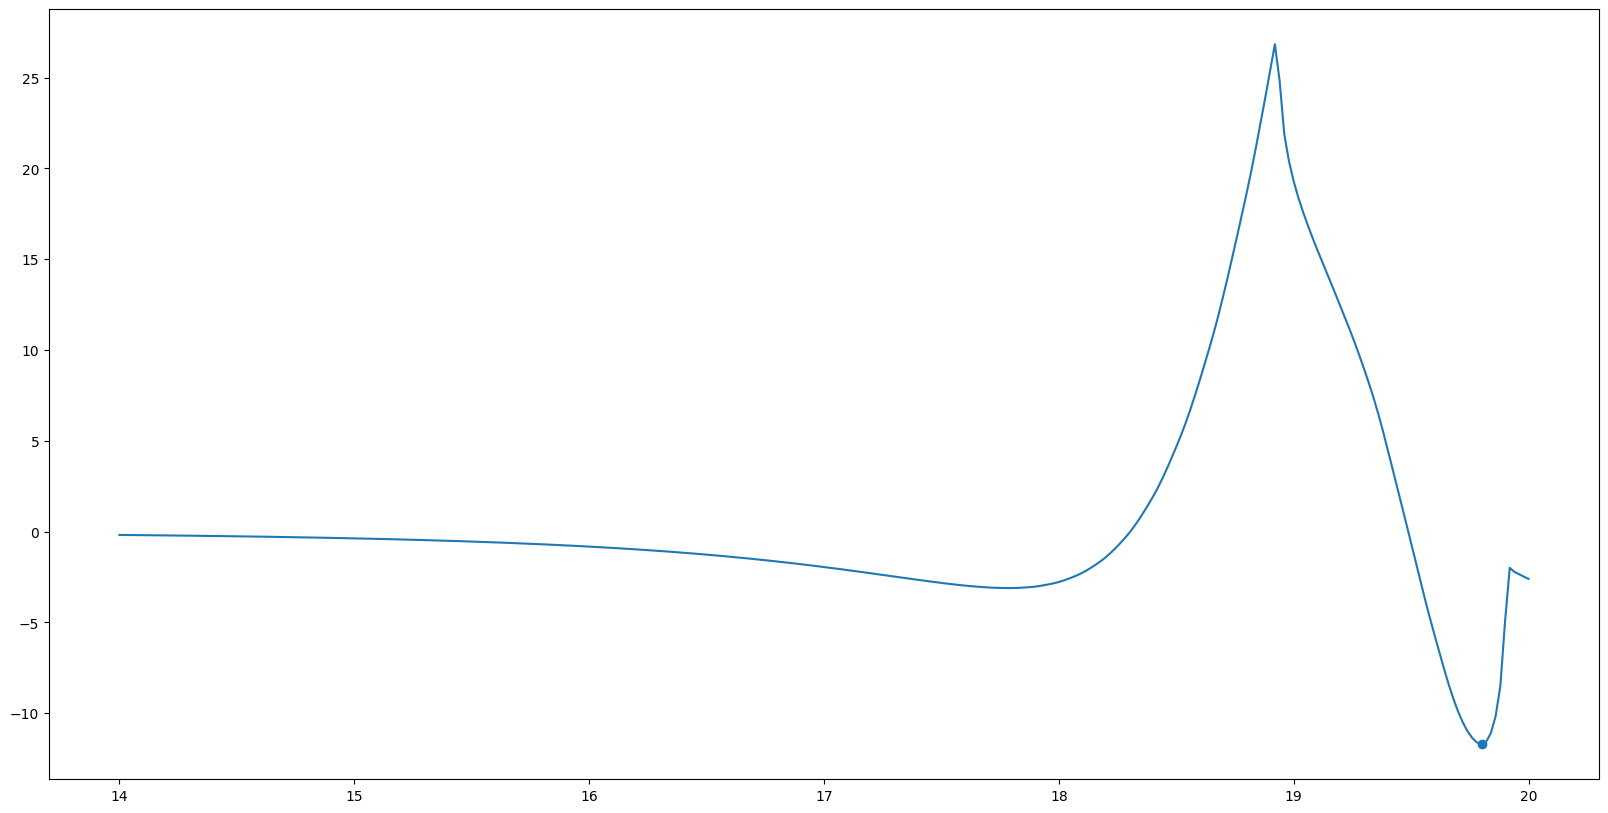

In [13]:
z = np.linspace(
            afmulator.scan_window[0][2],
            afmulator.scan_window[1][2] - afmulator.df_steps * afmulator.dz,
            afmulator.scan_dim[2] - afmulator.df_steps + 1,
        )

x, y = 14, 32
#plt.plot(z, afm_images[14, 32, :])
plt.plot(z, afm_images[x, y, :])
plt.scatter(z[np.argmin(afm_images, axis=2)[x, y]], afm_images[x,y, np.argmin(afm_images, axis=2)[x, y]])

In [24]:
tst = afm_images[:,:,::-1]

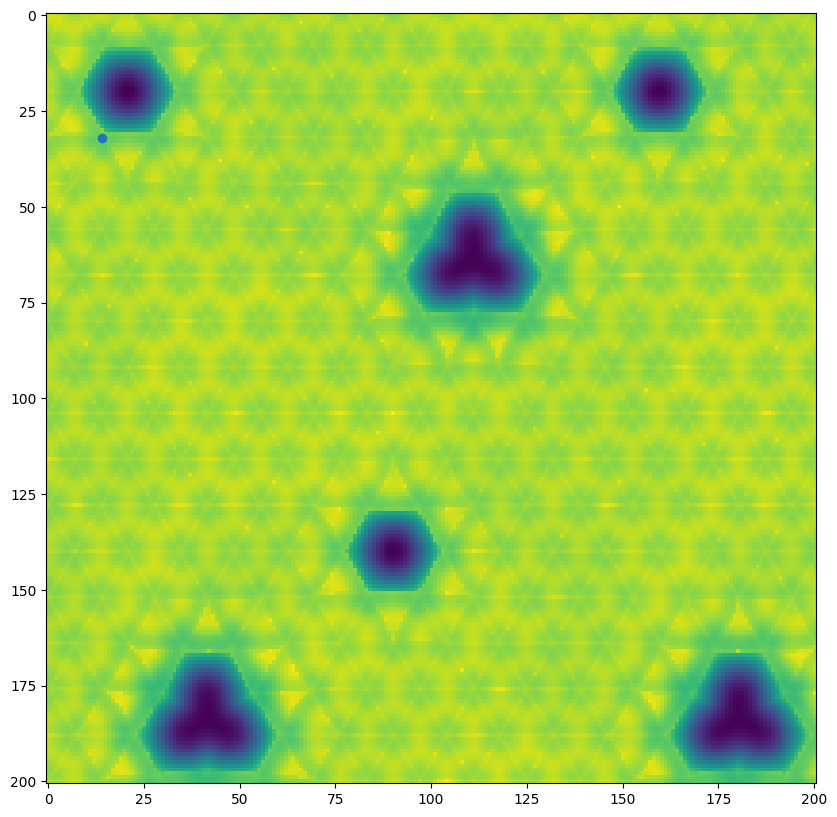

In [30]:
plot_surface(tst[:,:,20])
plt.scatter(14, 32)

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
 plotting slice # 250

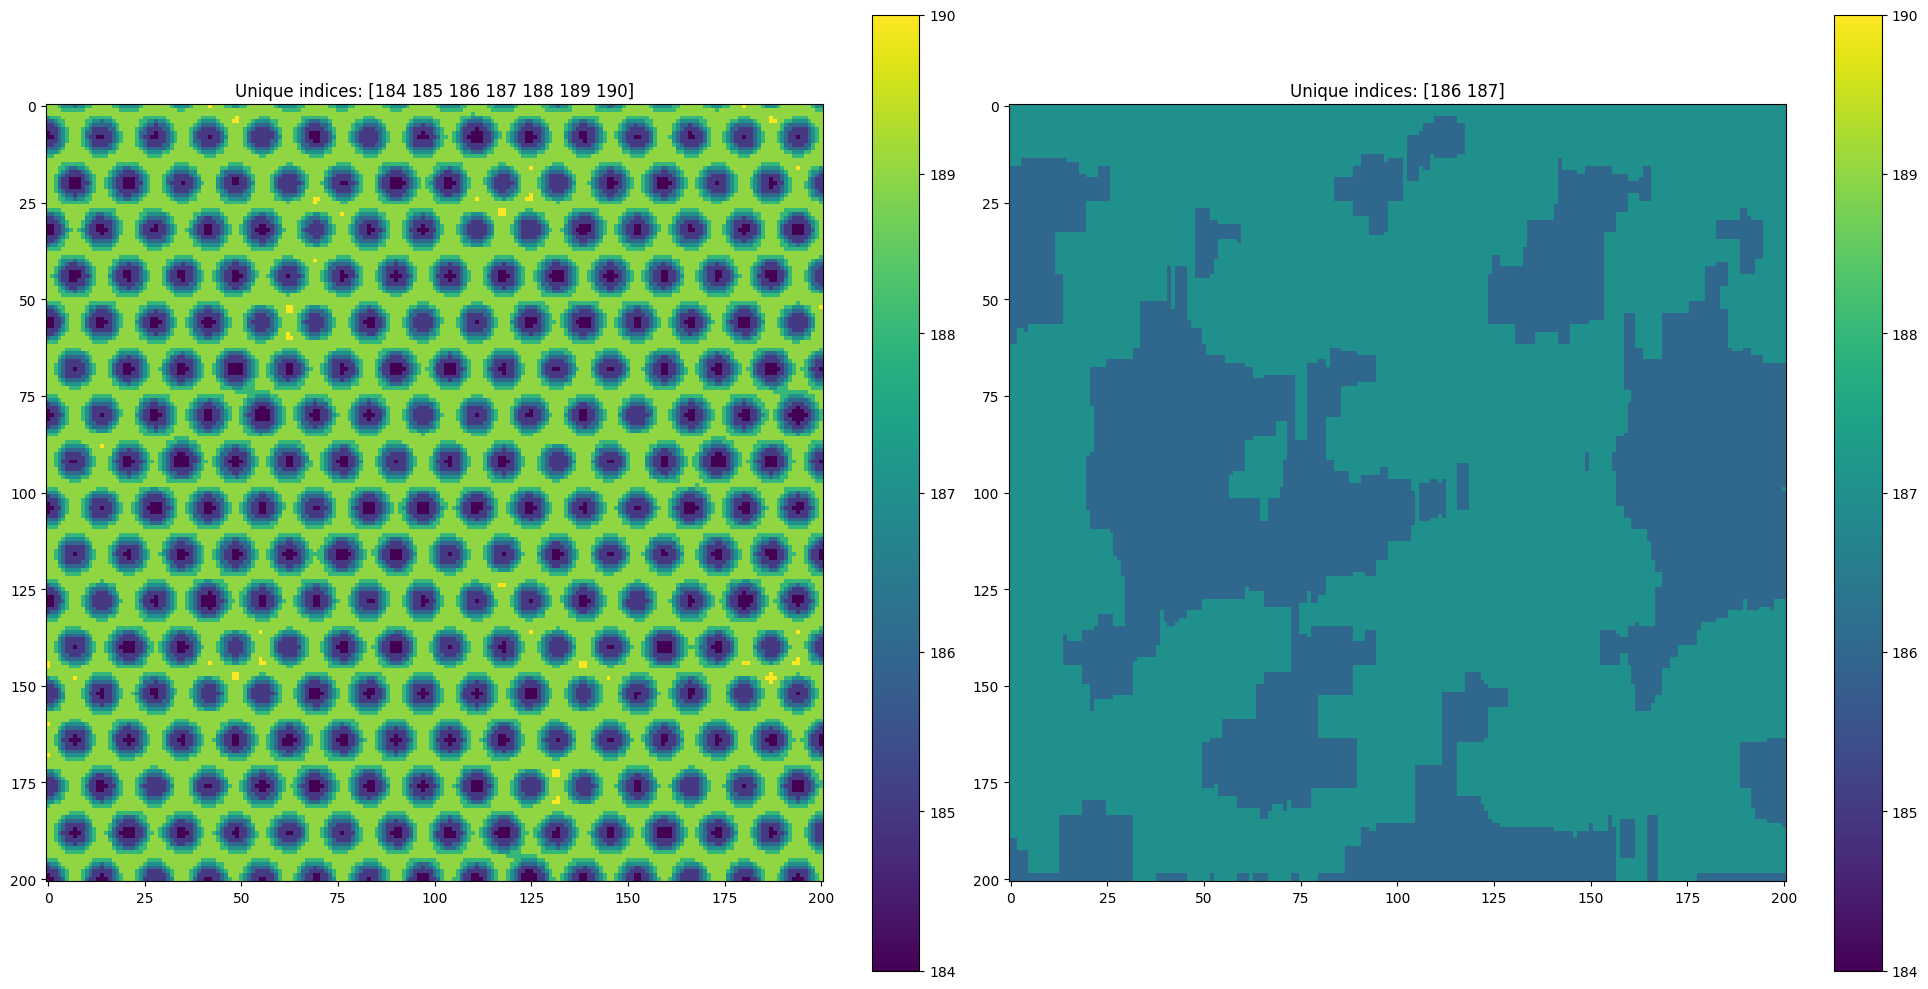

In [56]:
argmin_surface_and_blur("materials/pt_111_small.xyz")